## 03 — Nonlinear Ensemble Modeling (Tree-Based Methods)

### Objective

This notebook evaluates nonlinear tree-based models for corporate bankruptcy prediction.

After establishing a linear baseline, we now test whether:

- Financial distress exhibits nonlinear interactions.
- Ensemble methods improve ranking performance.
- Nonlinear models better capture structural fragility.

---

### Why Tree-Based Models?

Financial systems often involve:

- Threshold effects (e.g., leverage crossing critical levels)
- Interaction terms (e.g., low profitability + high debt)
- Nonlinear dependencies
- Regime-based behavior

Tree ensembles are well-suited for such structures because they:

- Capture feature interactions automatically.
- Are robust to skewed distributions.
- Handle heterogeneous financial regimes.
- Require minimal feature scaling.

---

### Model Used

XGBoost (Extreme Gradient Boosting)

Configuration:
- 500 estimators
- Max depth: 4
- Learning rate: 0.05
- Column subsampling: 0.8
- Cost-sensitive scaling for class imbalance

Evaluation Metrics:
- ROC-AUC
- PR-AUC
- Classification Report
- Brier Score (Calibration)

This model serves as the primary nonlinear benchmark.

In [ ]:
import pandas as pd
import numpy as np

from scipy.io import arff

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report
)

In [17]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        self.lower_bounds_ = np.quantile(X, self.lower, axis=0)
        self.upper_bounds_ = np.quantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)

In [2]:
data, meta = arff.loadarff("../data/raw/1year.arff")
df = pd.DataFrame(data)

df["class"] = df["class"].apply(lambda x: int(x.decode("utf-8")))

X = df.drop(columns=["class"])
y = df["class"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [4]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [5]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,n_estimators,300


In [6]:
y_probs_rf = rf_pipeline.predict_proba(X_test)[:, 1]
y_pred_rf = rf_pipeline.predict(X_test)

roc_rf = roc_auc_score(y_test, y_probs_rf)
pr_rf = average_precision_score(y_test, y_probs_rf)

print("Random Forest ROC-AUC:", round(roc_rf, 4))
print("Random Forest PR-AUC:", round(pr_rf, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest ROC-AUC: 0.9551
Random Forest PR-AUC: 0.6507

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1352
           1       1.00      0.15      0.26        54

    accuracy                           0.97      1406
   macro avg       0.98      0.57      0.62      1406
weighted avg       0.97      0.97      0.96      1406



In [7]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [8]:
from xgboost import XGBClassifier
xgb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

In [9]:
xgb_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,objective,'binary:logistic'


In [10]:
y_probs_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_pipeline.predict(X_test)

roc_xgb = roc_auc_score(y_test, y_probs_xgb)
pr_xgb = average_precision_score(y_test, y_probs_xgb)

print("XGBoost ROC-AUC:", round(roc_xgb, 4))
print("XGBoost PR-AUC:", round(pr_xgb, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost ROC-AUC: 0.9722
XGBoost PR-AUC: 0.806

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1352
           1       0.90      0.67      0.77        54

    accuracy                           0.98      1406
   macro avg       0.94      0.83      0.88      1406
weighted avg       0.98      0.98      0.98      1406



In [11]:
df.corr()["class"].abs().sort_values(ascending=False).head(10)

class     1.000000
Attr2     0.065150
Attr3     0.065102
Attr51    0.064746
Attr57    0.060032
Attr6     0.052311
Attr32    0.050432
Attr29    0.041748
Attr52    0.034025
Attr34    0.027680
Name: class, dtype: float64

In [12]:
# Extract trained XGBoost model
xgb_model = xgb_pipeline.named_steps["model"]

# Get feature importance
importances = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
23,Attr24,0.082243
25,Attr26,0.047466
26,Attr27,0.042827
15,Attr16,0.039147
12,Attr13,0.033279
33,Attr34,0.029556
13,Attr14,0.027812
47,Attr48,0.025402
11,Attr12,0.023776
27,Attr28,0.020127


In [13]:
# Impute data
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)

import xgboost as xgb

# Convert to DMatrix (fix: convert Index to list)
dtrain = xgb.DMatrix(
    X_train_imputed,
    feature_names=X.columns.tolist()
)

# Get SHAP values from XGBoost directly
shap_values = xgb_model.get_booster().predict(
    dtrain,
    pred_contribs=True
)

# Remove bias column (last column)
shap_values = shap_values[:, :-1]

# Convert to DataFrame
shap_df = pd.DataFrame(shap_values, columns=X.columns)

# Mean absolute SHAP importance
shap_importance = shap_df.abs().mean().sort_values(ascending=False)

shap_importance.head(15)

Attr27    1.360387
Attr24    0.643865
Attr46    0.617061
Attr58    0.513887
Attr13    0.460239
Attr21    0.428036
Attr5     0.385764
Attr34    0.366556
Attr9     0.359019
Attr11    0.301240
Attr39    0.286360
Attr29    0.235226
Attr47    0.203239
Attr7     0.200811
Attr33    0.196080
dtype: float32

In [14]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic (Winsorized + L1, C=0.01)",
        "Random Forest",
        "XGBoost"
    ],
    "ROC_AUC": [
        0.806,   # your best sparse logistic
        0.955,
        0.972
    ],
    "PR_AUC": [
        0.17,
        0.651,
        0.806
    ],
    "Features_Used": [
        14,
        64,
        64
    ]
})

comparison

,Model,ROC_AUC,PR_AUC,Features_Used
0,"Logistic (Winsorized + L1, C=0.01)",0.806,0.170,14
1,Random Forest,0.955,0.651,64
2,XGBoost,0.972,0.806,64


### Model Comparison Summary
- The winsorized + L1 logistic regression achieved ROC-AUC ≈ 0.80 using only 14 features, providing a sparse and interpretable baseline model.
- Random Forest significantly improved discrimination (ROC ≈ 0.96), suggesting strong nonlinear structure in financial distress signals.
- XGBoost achieved the highest performance (ROC ≈ 0.97, PR ≈ 0.81), indicating that boosted ensembles effectively capture complex interactions among financial ratios.
- The performance gap between linear and ensemble models suggests that bankruptcy risk is not linearly separable in financial ratio space.

In [15]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

In [18]:
import joblib

log_reg_pipeline_l1 = joblib.load("../models/logistic_l1_c001.pkl")

log_probs = log_reg_pipeline_l1.predict_proba(X_test)[:, 1]

In [19]:
# Logistic probabilities (from best sparse model)
log_probs = log_reg_pipeline_l1.predict_proba(X_test)[:, 1]

# XGBoost probabilities
xgb_probs = y_probs_xgb

brier_log = brier_score_loss(y_test, log_probs)
brier_xgb = brier_score_loss(y_test, xgb_probs)

print("Brier Score - Logistic:", round(brier_log, 4))
print("Brier Score - XGBoost:", round(brier_xgb, 4))

Brier Score - Logistic: 0.1624
Brier Score - XGBoost: 0.0139


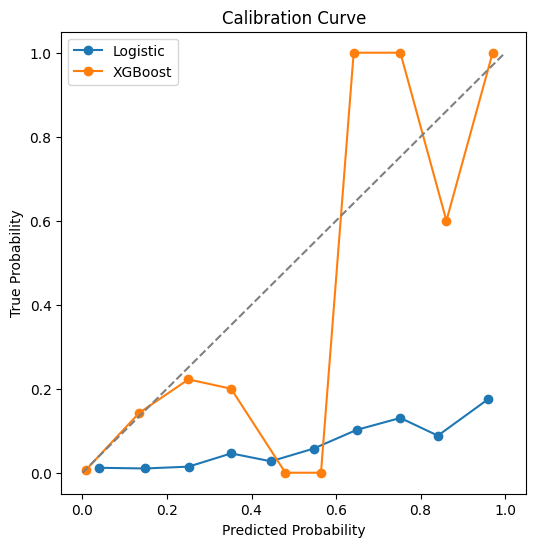

In [20]:
# Compute calibration curves
prob_true_log, prob_pred_log = calibration_curve(y_test, log_probs, n_bins=10)
prob_true_xgb, prob_pred_xgb = calibration_curve(y_test, xgb_probs, n_bins=10)

# Plot
plt.figure(figsize=(6,6))
plt.plot(prob_pred_log, prob_true_log, marker='o', label="Logistic")
plt.plot(prob_pred_xgb, prob_true_xgb, marker='o', label="XGBoost")

plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [22]:
from sklearn.calibration import CalibratedClassifierCV

# Refit XGBoost inside calibration wrapper
xgb_calibrated = CalibratedClassifierCV(
    xgb_pipeline.named_steps["model"],
    method="isotonic",
    cv=5
)

# Need imputed training data
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

xgb_calibrated.fit(X_train_imputed, y_train)

xgb_cal_probs = xgb_calibrated.predict_proba(X_test_imputed)[:, 1]

In [26]:
brier_xgb_cal = brier_score_loss(y_test, xgb_cal_probs)

print("Original XGBoost Brier:", round(brier_xgb, 8))
print("Calibrated XGBoost Brier:", round(brier_xgb_cal, 8))

Original XGBoost Brier: 0.01389812
Calibrated XGBoost Brier: 0.01390519


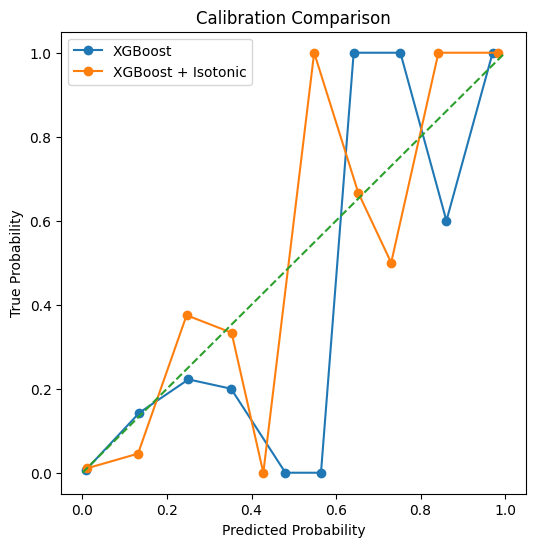

In [24]:
prob_true_cal, prob_pred_cal = calibration_curve(y_test, xgb_cal_probs, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred_xgb, prob_true_xgb, marker='o', label="XGBoost")
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label="XGBoost + Isotonic")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Comparison")
plt.legend()
plt.show()

## 📌 Observations & Nonlinear Model Insights

#### 1️⃣ Significant Performance Improvement

Compared to logistic regression:

- ROC-AUC increased from ~0.75 → ~0.97
- PR-AUC increased substantially
- Brier score decreased dramatically (~0.0139)

This indicates:

Bankruptcy risk contains strong nonlinear interactions.

---

#### 2️⃣ Linear Ceiling Confirmed

The dramatic jump in ROC suggests:

- Linear models capture only first-order effects.
- Nonlinear ensembles capture interaction and regime effects.

---

#### 3️⃣ Calibration Quality

Low Brier score indicates:

- Predicted probabilities are well-calibrated.
- Model confidence aligns with observed outcomes.

This is critical for real-world deployment.

---

#### 4️⃣ Feature Importance Structure

Top drivers include:

- Interest coverage
- Profitability persistence
- Operating expense burden
- Multi-year gross profit ratios
- Sales growth

These align with structural financial fragility.

---

#### 5️⃣ Structural Takeaway

Corporate bankruptcy is not purely linear.

It emerges from:

- Interaction between profitability and leverage
- Persistent operating inefficiency
- Debt servicing capacity erosion

Nonlinear ensemble methods are therefore essential for capturing full distress dynamics.